This file uploads, cleans and explains the used data


Sources : 
https://www.services-rte.com/fr/visualisez-les-donnees-publiees-par-rte/bourses-de-lelectricite-spot-france.html
https://transparency.entsoe.eu/market/energyPrices?appState=%7B%22sa%22%3A%5B%22BZN%7C10YFR-RTE------C%22%5D%2C%22st%22%3A%22BZN%22%2C%22mm%22%3Afalse%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22TABLE%22%2C%22df%22%3A%222026-01-01%22%2C%22tz%22%3A%22WET%22%7D


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Improting dataset
df = pd.read_csv("Data/raw/France sdac.csv")
df

,MTU (WET/WEST);Area;Sequence;Day-ahead Price (EUR/MWh);Intraday Period (WET/WEST);Intraday Price (EUR/MWh)
0,"01/01/2026 00:00:00 - 01/01/2026 00:15:00,""BZN..."
1,"01/01/2026 00:15:00 - 01/01/2026 00:30:00,""BZN..."
2,"01/01/2026 00:30:00 - 01/01/2026 00:45:00,""BZN..."
3,"01/01/2026 00:45:00 - 01/01/2026 01:00:00,""BZN..."
4,"01/01/2026 01:00:00 - 01/01/2026 01:15:00,""BZN..."
...,...
11891,"04/05/2026 21:45:00 - 04/05/2026 22:00:00,""BZN..."
11892,"04/05/2026 22:00:00 - 04/05/2026 22:15:00,""BZN..."
11893,"04/05/2026 22:15:00 - 04/05/2026 22:30:00,""BZN..."
11894,"04/05/2026 22:30:00 - 04/05/2026 22:45:00,""BZN..."


In [3]:
#Checking if datasets can be read correctly with one and several columns
if df.shape[1] == 1:
    df = df.iloc[:, 0].str.split(",", expand=True)
    df.columns = [ "MTU","Area","Sequence","Day-ahead Price (EUR/MWh)","Intraday Period","Intraday Price (EUR/MWh)"]
else:
    df = df.rename(columns={"MTU (WET/WEST)": "MTU","Intraday Period (WET/WEST)": "Intraday Period"})
df.head()

,MTU,Area,Sequence,Day-ahead Price (EUR/MWh),Intraday Period,Intraday Price (EUR/MWh)
0,01/01/2026 00:00:00 - 01/01/2026 00:15:00,"""BZN|FR""","""Without Sequence""","""78.11""","""""",""""";;;;;"
1,01/01/2026 00:15:00 - 01/01/2026 00:30:00,"""BZN|FR""","""Without Sequence""","""68.99""","""""",""""";;;;;"
2,01/01/2026 00:30:00 - 01/01/2026 00:45:00,"""BZN|FR""","""Without Sequence""","""69.75""","""""",""""";;;;/;"
3,01/01/2026 00:45:00 - 01/01/2026 01:00:00,"""BZN|FR""","""Without Sequence""","""58.72""","""""",""""";;;;;"
4,01/01/2026 01:00:00 - 01/01/2026 01:15:00,"""BZN|FR""","""Without Sequence""","""72.94""","""""",""""";;;;;"


In [4]:
#Cleaings columns that aren't needed for our research
df = df.drop(columns=["Area","Sequence","Intraday Period","Intraday Price (EUR/MWh)"])
df.head()

,MTU,Day-ahead Price (EUR/MWh)
0,01/01/2026 00:00:00 - 01/01/2026 00:15:00,"""78.11"""
1,01/01/2026 00:15:00 - 01/01/2026 00:30:00,"""68.99"""
2,01/01/2026 00:30:00 - 01/01/2026 00:45:00,"""69.75"""
3,01/01/2026 00:45:00 - 01/01/2026 01:00:00,"""58.72"""
4,01/01/2026 01:00:00 - 01/01/2026 01:15:00,"""72.94"""


In [5]:
#quotation marks issue, so Python can read numbers
df["Day-ahead Price (EUR/MWh)"] = (df["Day-ahead Price (EUR/MWh)"].astype(str) .str.replace('"', '', regex=False) .str.strip())
df["Day-ahead Price (EUR/MWh)"] = pd.to_numeric(df["Day-ahead Price (EUR/MWh)"], errors="coerce")
df.head()

,MTU,Day-ahead Price (EUR/MWh)
0,01/01/2026 00:00:00 - 01/01/2026 00:15:00,78.11
1,01/01/2026 00:15:00 - 01/01/2026 00:30:00,68.99
2,01/01/2026 00:30:00 - 01/01/2026 00:45:00,69.75
3,01/01/2026 00:45:00 - 01/01/2026 01:00:00,58.72
4,01/01/2026 01:00:00 - 01/01/2026 01:15:00,72.94


In [6]:
#Creating the main Variable 
df["negative_price"] = (df["Day-ahead Price (EUR/MWh)"] < 0).astype(int)
df.head()

,MTU,Day-ahead Price (EUR/MWh),negative_price
0,01/01/2026 00:00:00 - 01/01/2026 00:15:00,78.11,0
1,01/01/2026 00:15:00 - 01/01/2026 00:30:00,68.99,0
2,01/01/2026 00:30:00 - 01/01/2026 00:45:00,69.75,0
3,01/01/2026 00:45:00 - 01/01/2026 01:00:00,58.72,0
4,01/01/2026 01:00:00 - 01/01/2026 01:15:00,72.94,0


In [7]:
#Creating time Variable
df["start_time"] = df["MTU"].str.split(" - ").str[0]
df["start_time"] = pd.to_datetime(df["start_time"], dayfirst=True, errors="coerce")
df["hour"] = df["start_time"].dt.hour
df["month"] = df["start_time"].dt.month
df["weekday"] = df["start_time"].dt.day_name()
df["weekend"] = df["weekday"].isin(["Saturday", "Sunday"]).astype(int)
df.head()

,MTU,Day-ahead Price (EUR/MWh),negative_price,start_time,hour,month,weekday,weekend
0,01/01/2026 00:00:00 - 01/01/2026 00:15:00,78.11,0,2026-01-01 00:00:00,0.0,1.0,Thursday,0
1,01/01/2026 00:15:00 - 01/01/2026 00:30:00,68.99,0,2026-01-01 00:15:00,0.0,1.0,Thursday,0
2,01/01/2026 00:30:00 - 01/01/2026 00:45:00,69.75,0,2026-01-01 00:30:00,0.0,1.0,Thursday,0
3,01/01/2026 00:45:00 - 01/01/2026 01:00:00,58.72,0,2026-01-01 00:45:00,0.0,1.0,Thursday,0
4,01/01/2026 01:00:00 - 01/01/2026 01:15:00,72.94,0,2026-01-01 01:00:00,1.0,1.0,Thursday,0


In [ ]:
#Check for the proper dates
print("Start date:", df["start_time"].min())
print("End date:", df["start_time"].max())
print("Months included:", sorted(df["month"].dropna().unique()))

Start date: 2026-01-01 00:00:00
End date: 2026-05-04 22:45:00
Months included: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


In [ ]:
#Numbers check
print("Summary statistics for day-ahead prices:")
print(df["Day-ahead Price (EUR/MWh)"].describe())
print("\nCounts of negative and non-negative prices:")
print(df["negative_price"].value_counts())
print("\nPercentages of negative and non-negative prices:")
print(df["negative_price"].value_counts(normalize=True) * 100)

Summary statistics for day-ahead prices:
count    11896.000000
mean        62.172095
std         55.085447
min       -498.650000
25%         16.597500
50%         68.455000
75%        101.680000
max        291.100000
Name: Day-ahead Price (EUR/MWh), dtype: float64

Counts of negative and non-negative prices:
negative_price
0    10992
1      904
Name: count, dtype: int64

Percentages of negative and non-negative prices:
negative_price
0    92.400807
1     7.599193
Name: proportion, dtype: float64


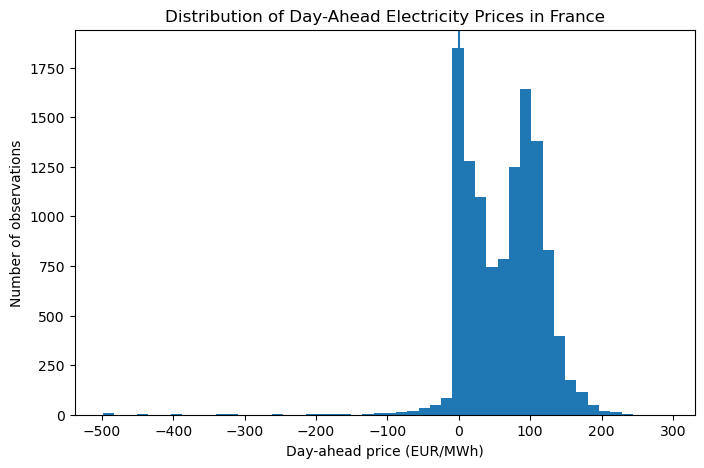

In [9]:
#Graph Price distribution
plt.figure(figsize=(8, 5))
plt.hist(df["Day-ahead Price (EUR/MWh)"].dropna(), bins=50)
plt.axvline(0)
plt.title("Distribution of Day-Ahead Electricity Prices in France")
plt.xlabel("Day-ahead price (EUR/MWh)")
plt.ylabel("Number of observations")
plt.show()

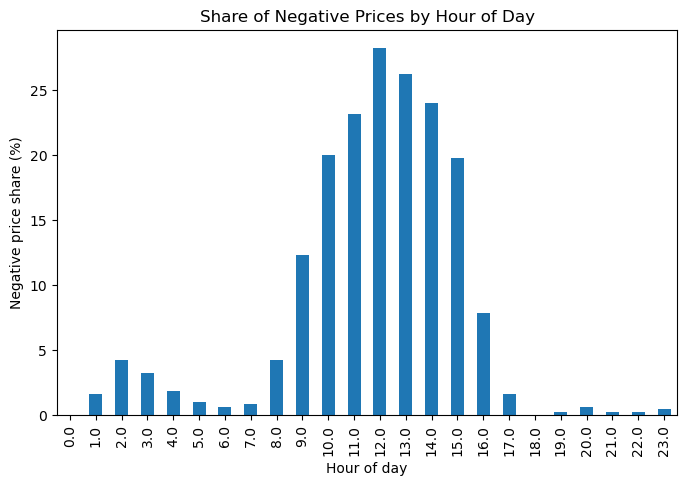

In [10]:
#Graph Negative prices by hour
negative_by_hour = df.groupby("hour")["negative_price"].mean() * 100
plt.figure(figsize=(8, 5))
negative_by_hour.plot(kind="bar")
plt.title("Share of Negative Prices by Hour of Day")
plt.xlabel("Hour of day")
plt.ylabel("Negative price share (%)")
plt.show()

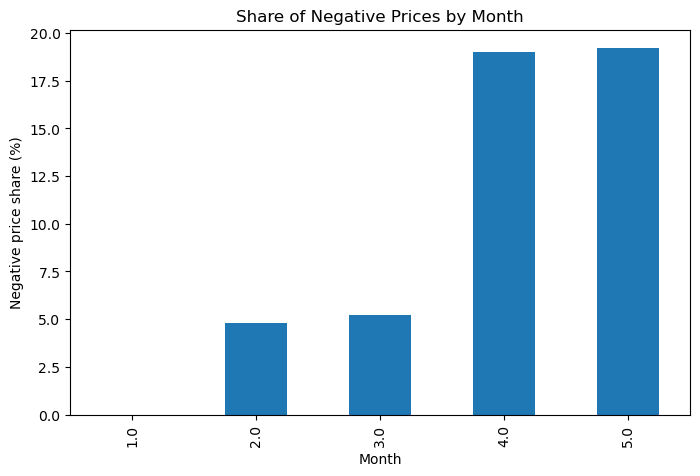

In [11]:
#Graph Negative prices by month
negative_by_month = df.groupby("month")["negative_price"].mean() * 100
plt.figure(figsize=(8, 5))
negative_by_month.plot(kind="bar")
plt.title("Share of Negative Prices by Month")
plt.xlabel("Month")
plt.ylabel("Negative price share (%)")
plt.show()

In [12]:
df2 = pd.read_csv('Data/raw/FrGen26.csv')  
print(df2.head(10))

  MTU (UTC),"Area","Production Type","Generation (MW)"
0  01/01/2026 00:00:00 - 01/01/2026 00:15:00,"BZN...  
1  01/01/2026 00:15:00 - 01/01/2026 00:30:00,"BZN...  
2  01/01/2026 00:30:00 - 01/01/2026 00:45:00,"BZN...  
3  01/01/2026 00:45:00 - 01/01/2026 01:00:00,"BZN...  
4  01/01/2026 01:00:00 - 01/01/2026 01:15:00,"BZN...  
5  01/01/2026 01:15:00 - 01/01/2026 01:30:00,"BZN...  
6  01/01/2026 01:30:00 - 01/01/2026 01:45:00,"BZN...  
7  01/01/2026 01:45:00 - 01/01/2026 02:00:00,"BZN...  
8  01/01/2026 02:00:00 - 01/01/2026 02:15:00,"BZN...  
9  01/01/2026 02:15:00 - 01/01/2026 02:30:00,"BZN...  


In [13]:
# Cleaning second generation dataset
df2 = df2.iloc[:, 0].str.split(",", expand=True)
# Rename columns
df2.columns = ["MTU", "Area", "Type", "MW"]
# Clean text columns
df2["MTU"] = df2["MTU"].astype(str).str.replace('"', '', regex=False).str.strip()
df2["Area"] = df2["Area"].astype(str).str.replace('"', '', regex=False).str.strip()
df2["Type"] = df2["Type"].astype(str).str.replace('"', '', regex=False).str.strip()
# Clean MW column
df2["MW"] = (df2["MW"] .astype(str) .str.replace('"', '', regex=False) .str.strip())
# Treat non-numeric entries as missing values
df2["MW"] = df2["MW"].replace(["N/A", "n/e", "-", ""], pd.NA)
# Convert generation to numeric
df2["MW"] = pd.to_numeric(df2["MW"], errors="coerce")
# Show rows where MW is actually numeric, because a lot of MW values are missing which is critical for further analysis
df2[df2["MW"].notna()].head()


,MTU,Area,Type,MW
103,02/01/2026 01:45:00 - 02/01/2026 02:00:00,BZN|FR,Biomass,190.70
104,02/01/2026 02:00:00 - 02/01/2026 02:15:00,BZN|FR,Biomass,276.23
105,02/01/2026 02:15:00 - 02/01/2026 02:30:00,BZN|FR,Biomass,276.26
106,02/01/2026 02:30:00 - 02/01/2026 02:45:00,BZN|FR,Biomass,276.40
107,02/01/2026 02:45:00 - 02/01/2026 03:00:00,BZN|FR,Biomass,276.06


In [14]:
# Check wind and solar rows
df2[df2["Type"].isin(["Wind Onshore", "Wind Offshore", "Solar"])].head()
df2[(df2["Type"].isin(["Wind Onshore", "Wind Offshore", "Solar"])) &(df2["MW"].notna())].head()

,MTU,Area,Type,MW
595783,02/01/2026 01:45:00 - 02/01/2026 02:00:00,BZN|FR,Solar,0.0
595784,02/01/2026 02:00:00 - 02/01/2026 02:15:00,BZN|FR,Solar,0.0
595785,02/01/2026 02:15:00 - 02/01/2026 02:30:00,BZN|FR,Solar,0.0
595786,02/01/2026 02:30:00 - 02/01/2026 02:45:00,BZN|FR,Solar,0.0
595787,02/01/2026 02:45:00 - 02/01/2026 03:00:00,BZN|FR,Solar,0.0


In [15]:
#Keeping only wind and solar, for the research question purposes
renewables = df2[df2["Type"].isin(["Wind Onshore", "Wind Offshore", "Solar"])].copy()
# Reshaping the dataset so that wind and solar become separate columns for future analysis
renewables_wide = renewables.pivot_table(index="MTU", columns="Type", values="MW", aggfunc="sum").reset_index()
renewables_wide.columns.name = None
# Again replacing missing generation values with 0
renewables_wide = renewables_wide.fillna(0)
# Create wind generation
renewables_wide["wind_generation_MW"] = (renewables_wide.get("Wind Onshore", 0) + renewables_wide.get("Wind Offshore", 0))
# Create solar generation
renewables_wide["solar_generation_MW"] = renewables_wide.get("Solar", 0)
# Keep only variables needed for the analysis
renewables_wide = renewables_wide[["MTU", "wind_generation_MW", "solar_generation_MW"]]
renewables_wide.head()

,MTU,wind_generation_MW,solar_generation_MW
0,01/01/2026 00:00:00 - 01/01/2026 00:15:00,0.0,0.0
1,01/01/2026 00:15:00 - 01/01/2026 00:30:00,0.0,0.0
2,01/01/2026 00:30:00 - 01/01/2026 00:45:00,0.0,0.0
3,01/01/2026 00:45:00 - 01/01/2026 01:00:00,0.0,0.0
4,01/01/2026 01:00:00 - 01/01/2026 01:15:00,0.0,0.0


In [16]:
merged_df = pd.merge(df, renewables_wide, on="MTU", how="inner")
merged_df.head()

,MTU,Day-ahead Price (EUR/MWh),negative_price,start_time,hour,month,weekday,weekend,wind_generation_MW,solar_generation_MW
0,01/01/2026 00:00:00 - 01/01/2026 00:15:00,78.11,0,2026-01-01 00:00:00,0.0,1.0,Thursday,0,0.0,0.0
1,01/01/2026 00:15:00 - 01/01/2026 00:30:00,68.99,0,2026-01-01 00:15:00,0.0,1.0,Thursday,0,0.0,0.0
2,01/01/2026 00:30:00 - 01/01/2026 00:45:00,69.75,0,2026-01-01 00:30:00,0.0,1.0,Thursday,0,0.0,0.0
3,01/01/2026 00:45:00 - 01/01/2026 01:00:00,58.72,0,2026-01-01 00:45:00,0.0,1.0,Thursday,0,0.0,0.0
4,01/01/2026 01:00:00 - 01/01/2026 01:15:00,72.94,0,2026-01-01 01:00:00,1.0,1.0,Thursday,0,0.0,0.0


In [17]:
renewables_wide[["wind_generation_MW", "solar_generation_MW"]].describe()


,wind_generation_MW,solar_generation_MW
count,35040.000000,35040.000000
mean,2333.317676,1069.280799
std,4165.544111,3073.276408
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,3372.212500,0.000000
max,19114.570000,19114.750000


In [18]:
renewables_wide[(renewables_wide["wind_generation_MW"] > 0) | (renewables_wide["solar_generation_MW"] > 0)].head()

,MTU,wind_generation_MW,solar_generation_MW
96,01/02/2026 00:00:00 - 01/02/2026 00:15:00,5607.28,0.0
97,01/02/2026 00:15:00 - 01/02/2026 00:30:00,5513.78,0.0
98,01/02/2026 00:30:00 - 01/02/2026 00:45:00,5448.29,0.0
99,01/02/2026 00:45:00 - 01/02/2026 01:00:00,5622.57,0.0
100,01/02/2026 01:00:00 - 01/02/2026 01:15:00,5792.67,0.0


In [19]:
#Checking if solar_generation is present and above 0
renewables_wide[renewables_wide["solar_generation_MW"] > 0].head()

,MTU,wind_generation_MW,solar_generation_MW
124,01/02/2026 07:00:00 - 01/02/2026 07:15:00,6228.19,370.67
125,01/02/2026 07:15:00 - 01/02/2026 07:30:00,6326.15,477.07
126,01/02/2026 07:30:00 - 01/02/2026 07:45:00,6309.37,651.60
127,01/02/2026 07:45:00 - 01/02/2026 08:00:00,6226.43,898.25
128,01/02/2026 08:00:00 - 01/02/2026 08:15:00,6270.89,1266.14


In [20]:
#Checking solar generation by hours
renewables_wide["start_time"] = renewables_wide["MTU"].str.split(" - ").str[0]
renewables_wide["start_time"] = pd.to_datetime( renewables_wide["start_time"], dayfirst=True, errors="coerce")
renewables_wide["hour"] = renewables_wide["start_time"].dt.hour
solar_by_hour = renewables_wide.groupby("hour")["solar_generation_MW"].mean()
solar_by_hour

hour
0        0.000000
1        0.000000
2        0.000000
3        0.000000
4       25.012048
5       66.944658
6      360.429459
7     1012.940692
8     1885.162555
9     2697.843370
10    3269.671438
11    3534.312760
12    3482.927390
13    3178.669336
14    2656.254075
15    1923.852753
16    1057.508397
17     364.540514
18     107.656014
19      37.201966
20       1.811760
21       0.000000
22       0.000000
23       0.000000
Name: solar_generation_MW, dtype: float64

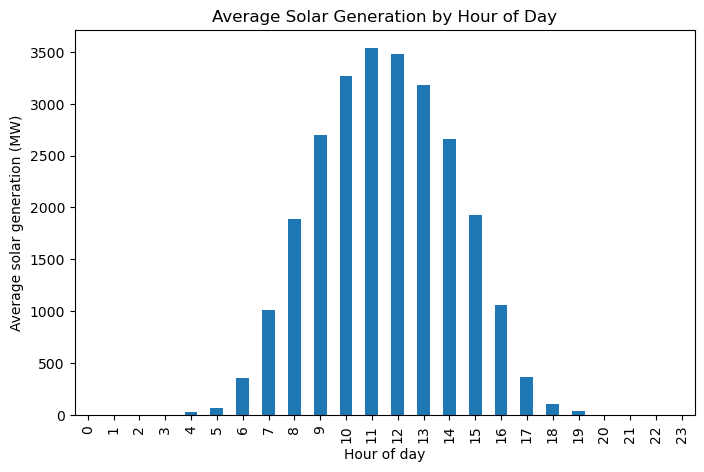

In [21]:
#Graph for understanding of solar energy
plt.figure(figsize=(8, 5))
solar_by_hour.plot(kind="bar")
plt.title("Average Solar Generation by Hour of Day")
plt.xlabel("Hour of day")
plt.ylabel("Average solar generation (MW)")
plt.show()

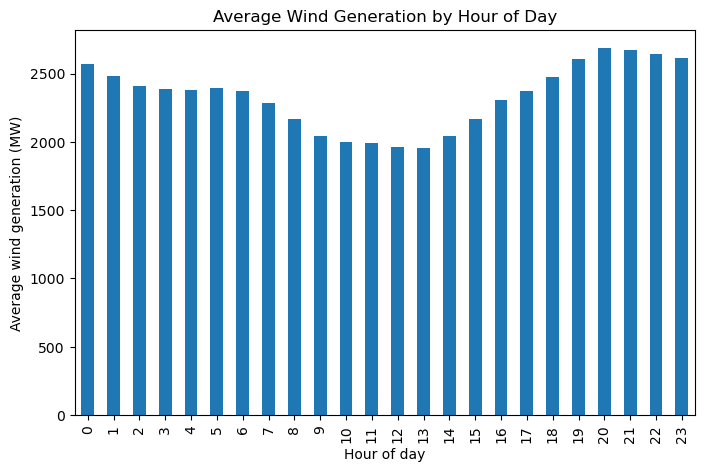

In [22]:
#Same for the wind
wind_by_hour = renewables_wide.groupby("hour")["wind_generation_MW"].mean()
plt.figure(figsize=(8, 5))
wind_by_hour.plot(kind="bar")
plt.title("Average Wind Generation by Hour of Day")
plt.xlabel("Hour of day")
plt.ylabel("Average wind generation (MW)")
plt.show()

In [23]:
#Merging price and renewable generation data
renewables_for_merge = renewables_wide[[ "MTU","wind_generation_MW", "solar_generation_MW"]].copy()
merged_df = pd.merge(df, renewables_for_merge, on="MTU", how="inner")
merged_df.head()

,MTU,Day-ahead Price (EUR/MWh),negative_price,start_time,hour,month,weekday,weekend,wind_generation_MW,solar_generation_MW
0,01/01/2026 00:00:00 - 01/01/2026 00:15:00,78.11,0,2026-01-01 00:00:00,0.0,1.0,Thursday,0,0.0,0.0
1,01/01/2026 00:15:00 - 01/01/2026 00:30:00,68.99,0,2026-01-01 00:15:00,0.0,1.0,Thursday,0,0.0,0.0
2,01/01/2026 00:30:00 - 01/01/2026 00:45:00,69.75,0,2026-01-01 00:30:00,0.0,1.0,Thursday,0,0.0,0.0
3,01/01/2026 00:45:00 - 01/01/2026 01:00:00,58.72,0,2026-01-01 00:45:00,0.0,1.0,Thursday,0,0.0,0.0
4,01/01/2026 01:00:00 - 01/01/2026 01:15:00,72.94,0,2026-01-01 01:00:00,1.0,1.0,Thursday,0,0.0,0.0


In [24]:
#Merge check
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11893 entries, 0 to 11892
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   MTU                        11893 non-null  object        
 1   Day-ahead Price (EUR/MWh)  11893 non-null  float64       
 2   negative_price             11893 non-null  int64         
 3   start_time                 11893 non-null  datetime64[ns]
 4   hour                       11893 non-null  float64       
 5   month                      11893 non-null  float64       
 6   weekday                    11893 non-null  object        
 7   weekend                    11893 non-null  int64         
 8   wind_generation_MW         11893 non-null  float64       
 9   solar_generation_MW        11893 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(2), object(2)
memory usage: 929.3+ KB


In [39]:
# Converting hour and month 
merged_df["hour"] = merged_df["hour"].astype(int)
merged_df["month"] = merged_df["month"].astype(int)
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11893 entries, 0 to 11892
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   MTU                        11893 non-null  object        
 1   Day-ahead Price (EUR/MWh)  11893 non-null  float64       
 2   negative_price             11893 non-null  int64         
 3   start_time                 11893 non-null  datetime64[ns]
 4   hour                       11893 non-null  int64         
 5   month                      11893 non-null  int64         
 6   weekday                    11893 non-null  object        
 7   weekend                    11893 non-null  int64         
 8   wind_generation_MW         11893 non-null  float64       
 9   solar_generation_MW        11893 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(4), object(2)
memory usage: 929.3+ KB


In [40]:
#Checking missing values
merged_df.isna().sum()

MTU                          0
Day-ahead Price (EUR/MWh)    0
negative_price               0
start_time                   0
hour                         0
month                        0
weekday                      0
weekend                      0
wind_generation_MW           0
solar_generation_MW          0
dtype: int64

In [26]:
#Comparations
generation_comparison = merged_df.groupby("negative_price")[["wind_generation_MW", "solar_generation_MW", "Day-ahead Price (EUR/MWh)"]].mean()
generation_comparison

,wind_generation_MW,solar_generation_MW,Day-ahead Price (EUR/MWh)
negative_price,,,
0,7055.831044,2577.383778,69.401099
1,4601.577013,10115.850520,-25.758108


In [27]:
#Renames for easier understanding
generation_comparison_named = generation_comparison.copy()
generation_comparison_named.index = ["Non-negative price", "Negative price"]
generation_comparison_named

,wind_generation_MW,solar_generation_MW,Day-ahead Price (EUR/MWh)
Non-negative price,7055.831044,2577.383778,69.401099
Negative price,4601.577013,10115.850520,-25.758108


In [ ]:
#Pure numbers
price_type_counts = merged_df["negative_price"].value_counts()
price_type_counts.index = ["Non-negative price", "Negative price"]
price_type_counts

Non-negative price    10989
Negative price          904
Name: count, dtype: int64

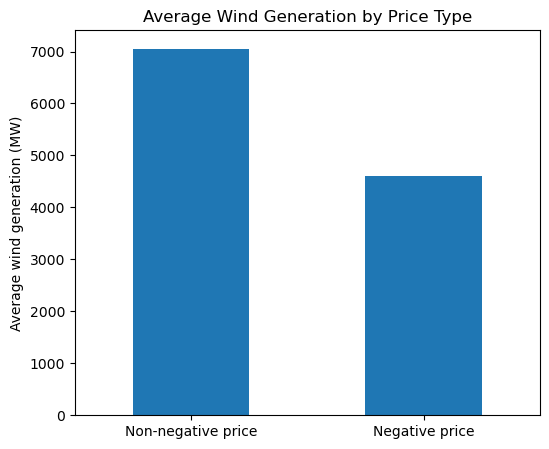

In [28]:
#Average wind generation by price type
wind_by_price_type = merged_df.groupby("negative_price")["wind_generation_MW"].mean()
wind_by_price_type.index = ["Non-negative price", "Negative price"]
#Graph
plt.figure(figsize=(6, 5))
wind_by_price_type.plot(kind="bar")
plt.title("Average Wind Generation by Price Type")
plt.xlabel("")
plt.ylabel("Average wind generation (MW)")
plt.xticks(rotation=0)
plt.show()

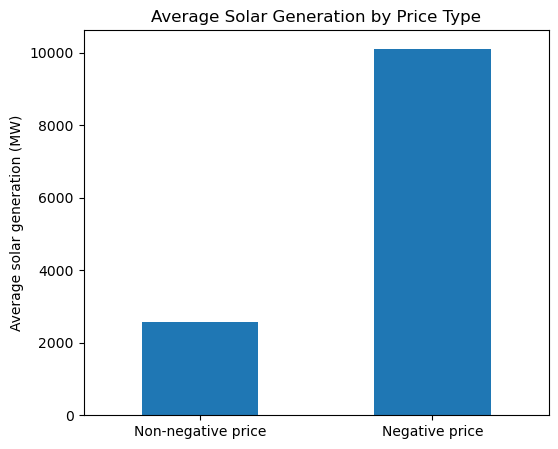

In [29]:
# Average solar generation by price type
solar_by_price_type = merged_df.groupby("negative_price")["solar_generation_MW"].mean()
solar_by_price_type.index = ["Non-negative price", "Negative price"]
#Graph
plt.figure(figsize=(6, 5))
solar_by_price_type.plot(kind="bar")
plt.title("Average Solar Generation by Price Type")
plt.xlabel("")
plt.ylabel("Average solar generation (MW)")
plt.xticks(rotation=0)
plt.show()

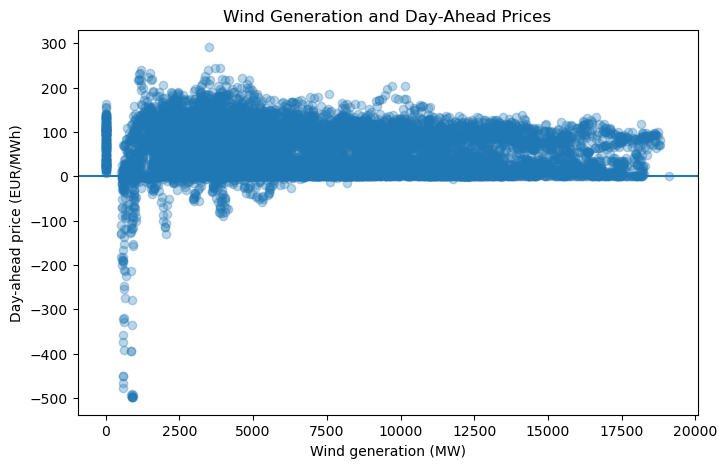

In [30]:
# Scatter graph of wind generation and price
plt.figure(figsize=(8, 5))
plt.scatter(
    merged_df["wind_generation_MW"],
    merged_df["Day-ahead Price (EUR/MWh)"],
    alpha=0.3
)
plt.axhline(0)
plt.title("Wind Generation and Day-Ahead Prices")
plt.xlabel("Wind generation (MW)")
plt.ylabel("Day-ahead price (EUR/MWh)")
plt.show()

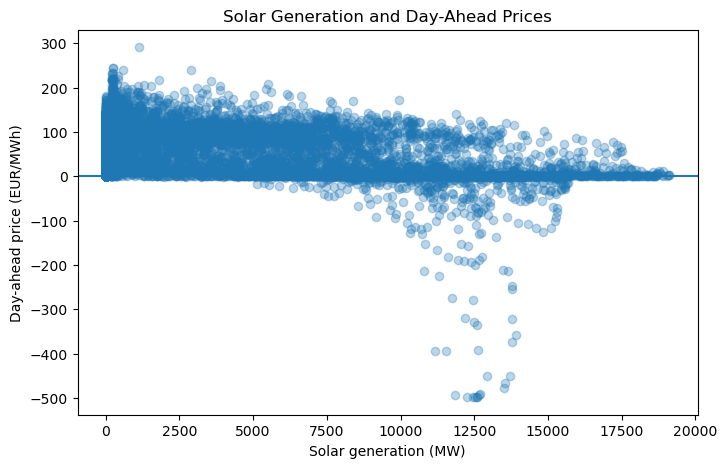

In [31]:
# Same for solar generation and price
plt.figure(figsize=(8, 5))
plt.scatter(
    merged_df["solar_generation_MW"],
    merged_df["Day-ahead Price (EUR/MWh)"],
    alpha=0.3
)
plt.axhline(0)
plt.title("Solar Generation and Day-Ahead Prices")
plt.xlabel("Solar generation (MW)")
plt.ylabel("Day-ahead price (EUR/MWh)")
plt.show()

In [32]:
# Correlation table for price and renewable generation
correlation_table = merged_df[["Day-ahead Price (EUR/MWh)", "negative_price", "wind_generation_MW", "solar_generation_MW"]].corr()
correlation_table

,Day-ahead Price (EUR/MWh),negative_price,wind_generation_MW,solar_generation_MW
Day-ahead Price (EUR/MWh),1.000000,-0.457785,-0.119660,-0.434765
negative_price,-0.457785,1.000000,-0.145703,0.433178
wind_generation_MW,-0.119660,-0.145703,1.000000,-0.264460
solar_generation_MW,-0.434765,0.433178,-0.264460,1.000000


In [33]:
# Hourly Summary of negative prices and renewable generation
hourly_summary = merged_df.groupby("hour")[["negative_price", "wind_generation_MW", "solar_generation_MW"]].mean()
# Convert negative_price from proportion to percentage for the research purposes
hourly_summary["negative_price"] = hourly_summary["negative_price"] * 100
hourly_summary

,negative_price,wind_generation_MW,solar_generation_MW
hour,,,
0.0,0.000000,7557.737429,0.000000
1.0,1.626016,7297.031768,0.000000
2.0,4.242424,7087.411030,0.000000
3.0,3.225806,7022.389819,0.000000
4.0,1.814516,7006.887056,73.624173
5.0,1.008065,7049.149940,197.054839
6.0,0.604839,6987.410464,1060.941552
7.0,0.806452,6715.164012,2981.639940
8.0,4.233871,6381.986512,5549.067198


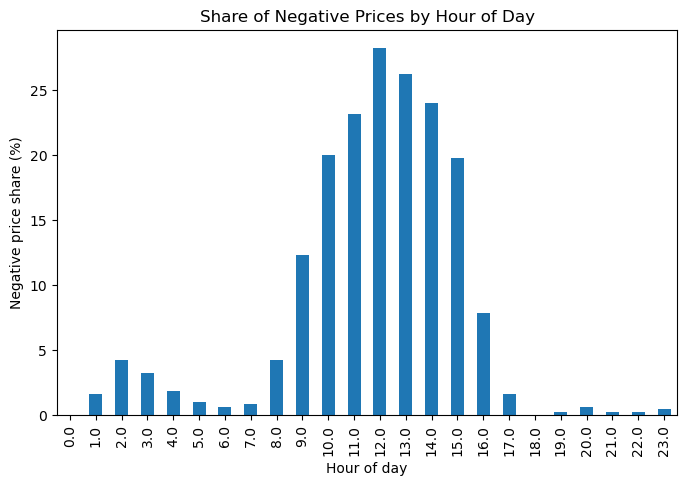

In [34]:
# Final graph.Negative prices by hour using the final merged dataset
plt.figure(figsize=(8, 5))
hourly_summary["negative_price"].plot(kind="bar")
plt.title("Share of Negative Prices by Hour of Day")
plt.xlabel("Hour of day")
plt.ylabel("Negative price share (%)")
plt.show()

In [35]:
# Same for mounthly
monthly_summary = merged_df.groupby("month")[["negative_price", "wind_generation_MW", "solar_generation_MW"]].mean()
monthly_summary["negative_price"] = monthly_summary["negative_price"] * 100
monthly_summary

,negative_price,wind_generation_MW,solar_generation_MW
month,,,
1.0,0.000000,7746.796062,1483.679792
2.0,4.799107,9294.783743,2183.298523
3.0,5.220613,6179.631967,4071.342860
4.0,18.993056,4975.381642,4823.637677
5.0,19.210526,2581.796684,3167.284895


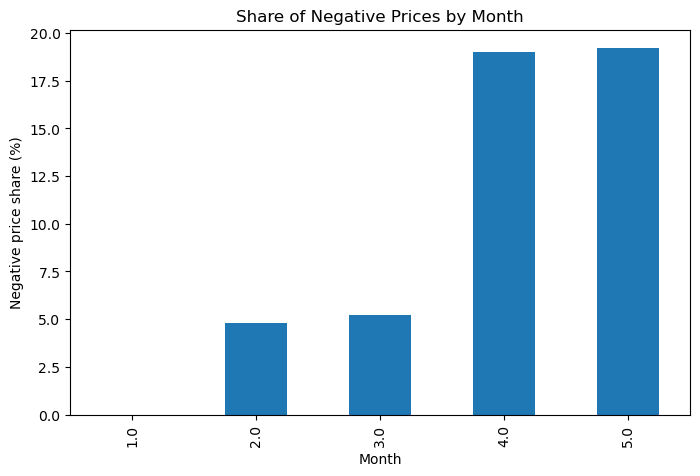

In [36]:
# Second final graph. Negative prices by month using the final merged dataset
plt.figure(figsize=(8, 5))
monthly_summary["negative_price"].plot(kind="bar")
plt.title("Share of Negative Prices by Month")
plt.xlabel("Month")
plt.ylabel("Negative price share (%)")
plt.show()

In [37]:
#Exporting data
df.to_csv("Data/processed/france_prices_clean.csv", index=False)
df2.to_csv("Data/processed/france_generation_clean.csv", index=False)
merged_df.to_csv("Data/processed/france_prices_generation_merged.csv", index=False)
generation_comparison_named.to_csv("Data/processed/generation_comparison_by_price_type.csv")
correlation_table.to_csv("Data/processed/correlation_table.csv")